In [1]:
import sys
sys.path.append("..")  # so Python can find the "core" package one level up

import matplotlib.pyplot as plt
import seaborn as sns

from core.data.preprocess import MovieDataPreprocessor

pipeline = (
    MovieDataPreprocessor()
    .load_raw_data()
    .build_movies_full()
    .build_text_corpus()
    .build_user_item_matrix()
)

# Expose familiar variable names so the analysis cells below
# (sparsity, rating distribution, missing values) keep working unchanged.
ratings = pipeline._ratings
movies = pipeline._movies
links = pipeline._links
movies_full = pipeline.movies_full
text_corpus = pipeline.text_corpus
user_item_matrix = pipeline.user_item_matrix

print(user_item_matrix.shape, text_corpus.shape)

(610, 9724) (3537, 4)


In [2]:
# How many unique users / movies actually appear in the ratings data?
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique() 
n_ratings = len(ratings)

# Sparsity = % of the user-item matrix that has NO rating.
# High sparsity (~98%+) is normal for recommender datasets, but it's
# exactly why plain CF struggles for new users/movies (cold-start).
sparsity = 1- (n_ratings / (n_users * n_movies))

print(f"Unique users: {n_users}")
print(f"Unique movies rated: {n_movies}")
print(f"Total ratings: {n_ratings}")
print(f"Matrix Sparsity: {sparsity:.4%}")



Unique users: 610
Unique movies rated: 9724
Total ratings: 100836
Matrix Sparsity: 98.3000%


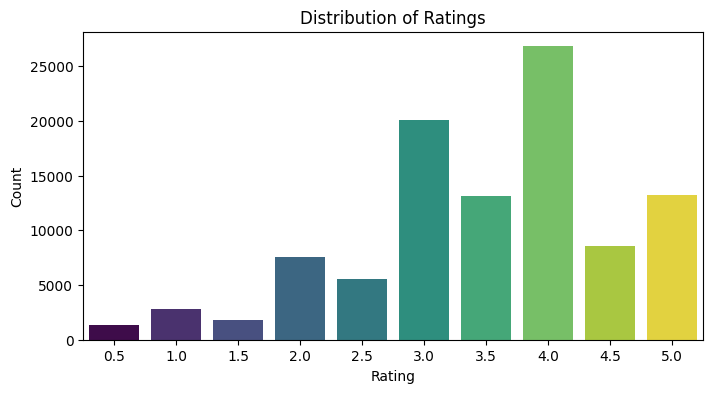

Missing values in movies:
 movieId    0
title      0
genres     0
dtype: int64

Missing values in links:
 movieId    0
imdbId     0
tmdbId     8
dtype: int64


In [3]:
# How are ratings spread out? (0.5 to 5.0 in 0.5 steps)
# This matters because a skewed distribution (e.g. mostly 3-5 stars)
# affects how we interpret RMSE/MAE later in evaluation.

plt.figure(figsize=(8, 4))

# hue=x + legend=False avoids the seaborn deprecation warning
sns.countplot(x='rating', data=ratings, hue='rating', palette='viridis', legend=False)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Check for missing values in movies/links —
# some movies may have no tmdbId, which means no plot overview later.
print("Missing values in movies:\n", movies.isnull().sum())
print("\nMissing values in links:\n", links.isnull().sum())


In [4]:
# Split ratings 80/20 per-user, on a fixed grid matching the full matrix.
train_matrix, test_df = pipeline.train_test_split(test_frac=0.2, seed=42)

print("Train matrix shape:", train_matrix.shape)
print("Test set size:", len(test_df))

# Sanity checks — these should all hold true if the split logic is correct:
# 1. Train matrix shape == full user_item_matrix shape (same grid)
assert train_matrix.shape == pipeline.user_item_matrix.shape, "Grid mismatch!"

# 2. Every user still has at least one training rating
n_users_with_train_data = train_matrix.notna().any(axis=1).sum()
print("Users with at least 1 train rating:", n_users_with_train_data, "/", train_matrix.shape[0])

# 3. How many movies have ZERO ratings in train (pure cold-start items)?
cold_start_movies = (train_matrix.notna().sum(axis=0) == 0).sum()
print("Movies with 0 train ratings (cold-start):", cold_start_movies)

Train matrix shape: (610, 9724)
Test set size: 19940
Users with at least 1 train rating: 610 / 610
Movies with 0 train ratings (cold-start): 734


In [5]:
import sys
sys.path.append("..")
from core.models.svd import SVDRecommender
import numpy as np

# Fit on the TRAIN split only — fitting on the full matrix here would leak
# test ratings into training, making the evaluation meaningless.
svd = SVDRecommender(n_factors=20).fit(train_matrix)

# Predict a rating for every (user, movie) pair in the held-out test set.
test_df["predicted"] = test_df.apply(
    lambda row: svd.predict(row["userId"], row["movieId"]), axis=1
)

valid = test_df.dropna(subset=["predicted"])
print(f"Valid predictions: {len(valid)} / {len(test_df)}")

errors = valid["rating"] - valid["predicted"]
rmse = np.sqrt((errors ** 2).mean())
mae = errors.abs().mean()
print(f"SVD (k=20) — RMSE: {rmse:.4f}, MAE: {mae:.4f}")

# Trivial baseline: predict each user's own average rating.
# If SVD can't clearly beat "do nothing clever", that's worth knowing
# and reporting honestly — not a coding mistake, a real ML finding.
user_means = train_matrix.mean(axis=1)
baseline_errors = valid["rating"] - valid["userId"].map(user_means)
baseline_rmse = np.sqrt((baseline_errors ** 2).mean())
baseline_mae = baseline_errors.abs().mean()
print(f"User-mean baseline — RMSE: {baseline_rmse:.4f}, MAE: {baseline_mae:.4f}")

Valid predictions: 19940 / 19940
SVD (k=20) — RMSE: 0.8723, MAE: 0.6662
User-mean baseline — RMSE: 0.9435, MAE: 0.7347
